# Self-supervised FCNs for Monocular Depth-estimation



## Abstract

This project aims to develop a model for monocular depth estimation using a self-supervised training approach, eliminating the need for ground truth disparity data. Self-supervised methods offer a cost-effective alternative to supervised learning, leveraging readily available stereo image pairs.

Inspired by the work of [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677), we implement a fully convolutional network (FCN) architecture for disparity prediction. The model is trained on the KITTI stereo dataset, utilizing data augmentation techniques like random horizontal flips and color adjustments to improve generalization. Our approach incorporates a loss function combining appearance, disparity smoothness, left-right consistency, and disparity spread loss terms to guide the learning process.


## Team Members & Contributions
For this project we largely worked together, and both of us contributed to all sections, however we started the project with these focuses:

- Oliver Tattersall
    - Reconstruction, Loss Functions, Training Loop
- Owen Waldron
    - Data Loading and Transforms, Model, Validation


## Data Synthesis

We will be using a subset of the [KITTI stereo dataset](https://www.cvlibs.net/datasets/kitti/eval_scene_flow.php?benchmark=stereo) for stereo disparity pairs. This subset is the KITTI 2015 stereo benchmark, and represents 200 training and testing stereo pairs taken from real world driving situations.

**To download the dataset we used, we've uploaded a zip of our `datasets` folder at this google drive link: https://drive.google.com/file/d/1xltc0UvnsmsAEhGErjHEUHPkXvTcu3ZM/view?usp=sharing**

We take advantage of pytorch's builtin `Kitti2015Stereo` dataloader, however we are interested in exclusivly the stereo image pairs, so we disregard the disparity map estimates and valid masks.

To augment training data, we first prepare the following transformations that follow the `StereoMatchingDataset` API. Note that that `StereoMatchingDataset` applies the transformations to the left & right images, as well as the disparities & valid_masks. These last two aren't used in training, so we do not bother transforming them in our transformations.

We use the same data augmentations as [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677), including a random horizontal flip, as well as a random color augment. It is important that during the random flip, left and right images are swapped accordingly.

Also, the model architecture requires that the image dimensions be multiples of 128, so a `CropToMultiple` transformation was created to ensure this.

We also tried using a random resize crop similar to Assignemnt 5, but found that this resulted in much poorer results. This is likely due to the network needing context of the entire scene to esitmate disparities, and disparity scale not being consistent with resizing.

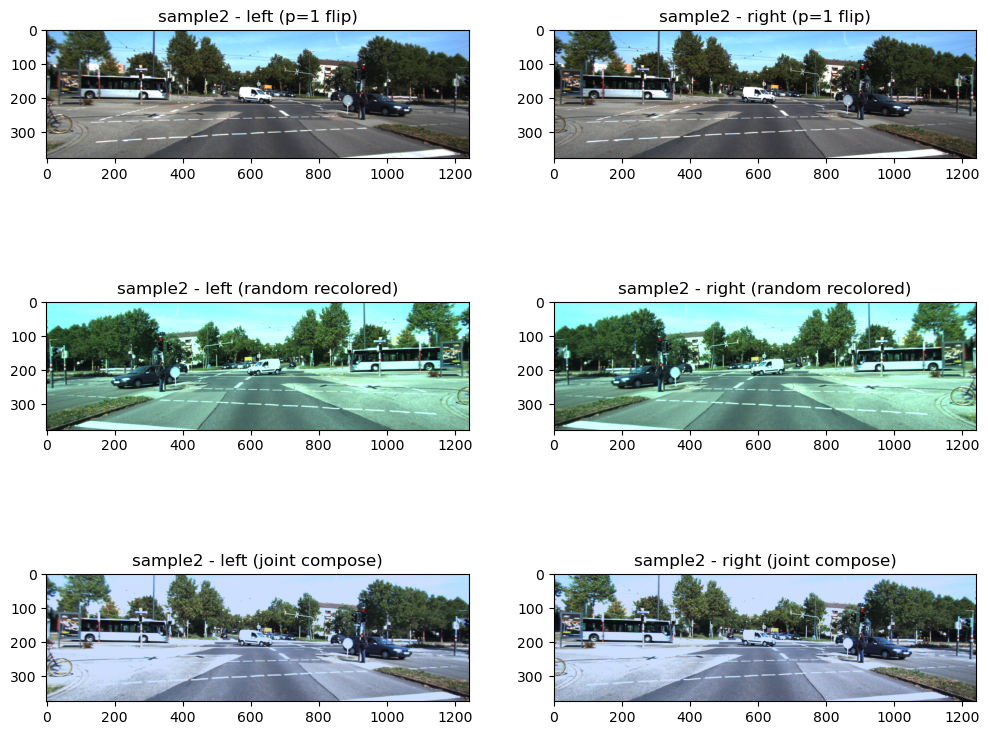

We will have 3 seperate data loaders for different training contexts.

## Model

We follow the fully convolutional network architecture described by [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677) with a few important differences. The model consists into an encoder and decoder. At a high level, the encoder recognizes featueres and the decoder reconstructs a disparity map given these identified features via skip connections from the encoder and upsampling.


The output of the network is **two** disparity maps for the left & right images respectively. In training, both are used to imporve the output, but in evalution only the left is used. The "disparities" are ranged [0, 1] and represent a scaled multiple of the image width.


The key differences we made to improve our results were:
*   **Using a ReLU activation function as opposed to sigmoid for disparity outputs.** This was because we found sigmoid had the whole disparity map tend towards 0.5, which is not what we'd expect for the output.
*   **Having the scale be a learnable parameter.** This allowed the model to learn how to scale its output appropriately.
*   **Using exponentiated linear units (ELU) as an intermdiate activation function.** After experimentaion, we found this worked best for our model. This is likely because it encourages smoothness and centers around 0 since it allows negative values.



The decoder features several "upconvolutions" steps. We experimented using both transpose convolutions (where model learns to upsample) and a more simple bilinear interpolation followed by a convolution. We found transposed convolutions resulted in "checkerboard artifacts" as described by [\[Odena, et al., 2016\]](https://distill.pub/2016/deconv-checkerboard/). You can observe this example of our trained output with transpose convolutions:

<img src="images/screenshots/checkerboard.png" width=1400>


## Reconstructing the image from the disparity

To test the outputted disparities, part of the error is recreating the right image/left image and comparing to the actual right image/left image. To do that we created a function that shifts pixel location based on the disparity shift, and the normalizes and uses torch's bilinear grid sample to create a new image. The function assumes recreating a right image, so we have a wrapper that multiplies by -1 when recreating the left image instead.

Example on a ground truth image

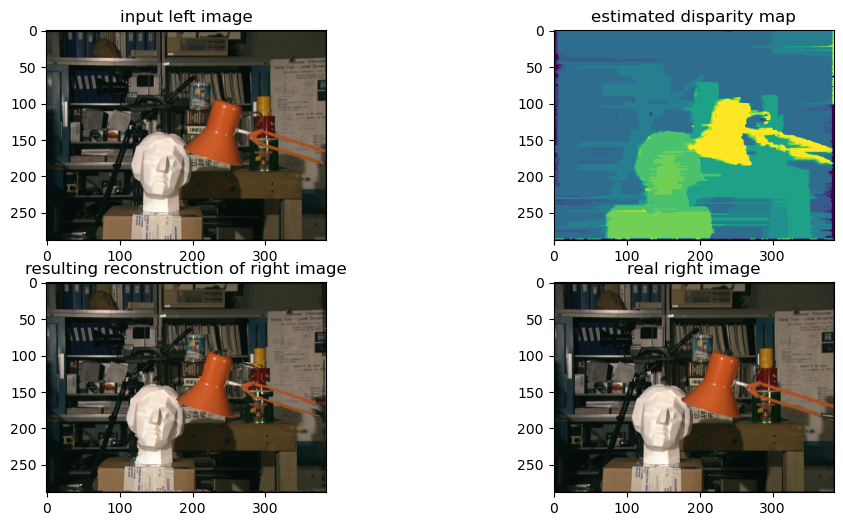

The untrained model's attempt

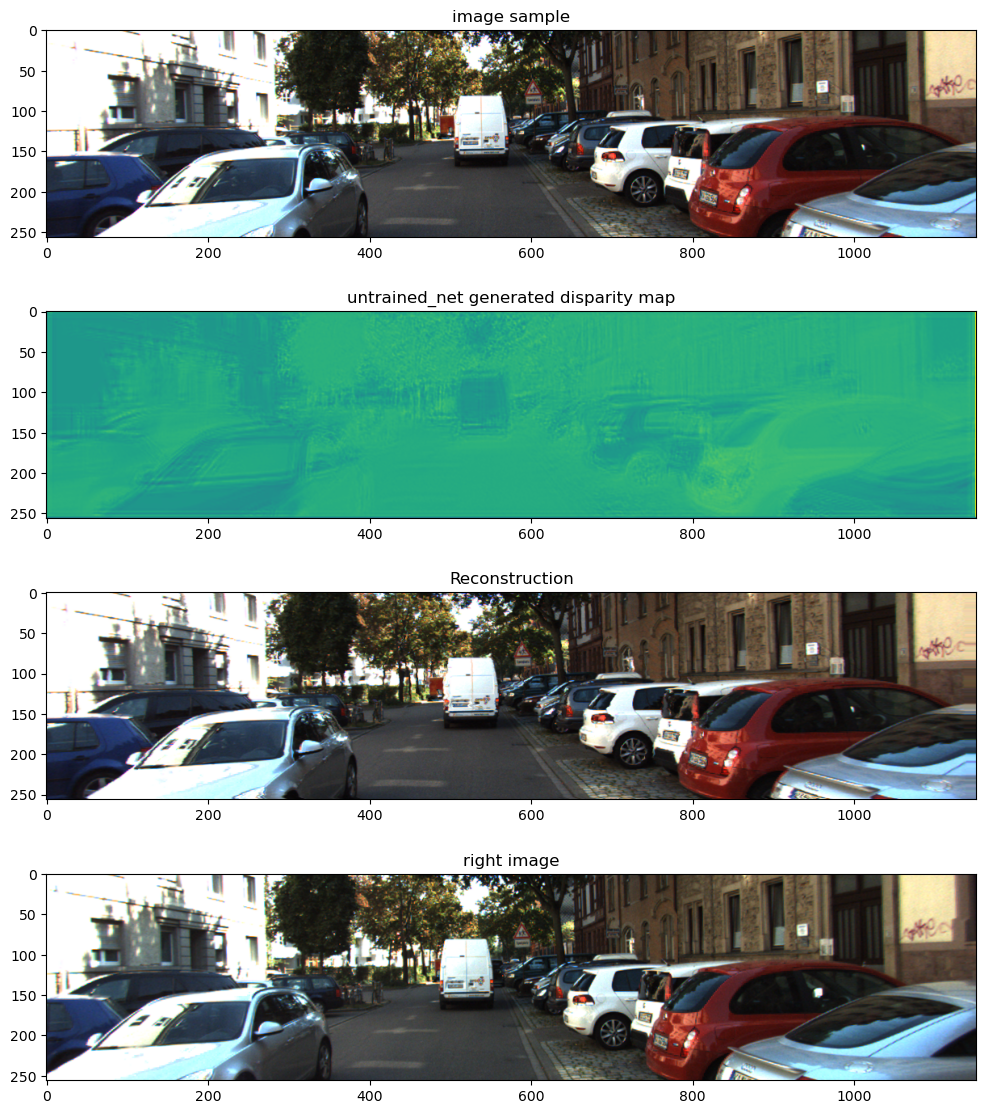

## Loss Function

We took inspiration for our loss function from  [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677), which consisted of 3 parts: the appearance loss, the disparity smoothness loss, and the left-right consistency loss.

The appearance loss is the loss of the reconstructed images to their real counterparts. The paper initially used a mixture of SSIM(Structural Similarity Index Measure) and L1 norm, however we found that using a mean-square error resulted in much better results that more accurately generated the depth maps.

The disparity smoothness loss is a loss to reduce jumps in disparity, except possible at object boundaries. It does this by multiplying the gradient of the derivate by the negative exponential of the gradient of the image, for both x and y directions. The formula for this is $\frac{1}{N}Σ_{i,j}|∂_xd_{ij}|e^{-\|∂_xI_{ij}\|} + |∂_yd_{ij}|e^{-\|∂_yI_{ij}\|}$, which is applied to both the left and right image/disparity pairs generated by the model. In testing the model, we found that the disparities tended to be the same across the horizontal and simply decrease as it went upward, so we added a scaling factor to both the x and y terms, to increase the cost for disparity jumps in the y direction. This ended up encouraging better object prediction and separation, however the disparity line artifacts can still be found.

The left-right consistency loss is to ensure that the left and right disparity maps generated are closely related, by checking if the disparity on the shifted right disparity map are the same as the left disparity map. The formula for this function is $\frac{1}{N}Σ_{ij}|d_{ij}^l - d_{ij + d_{ij}^l}^r|$.

While this function allows for more smoothness than a simple photo-consistency term, an issue we ran into is that the disparity map being 0 results in a zero loss for both the disparity smoothness and left-right consistency losses. We tried to reduce the effect of these losses so the model didn't optimize for generating 0 disparity maps by decreasing the associated coefficient, however this ended up with very poor and spotty results. Instead, we added a loss term to encourage more uniformity and spread through the disparity_uniform_loss function, which is a negative exponential on the variance of the disparity. This allowed us to keep the other errors significant without running into the 0 disparity maps issue. None the less, the 0 disparity map was still a local minimum, so we would have to rerun the model whenever its first state was a 0 disparity map.


## Trainer


To train the model, we set up 2 simple, reusable functions that train by running each item getting the outputted left and right disparity maps, reconstructing the left and right image, and passing to loss function, from which we can store the loss value, and back propogate. Once it is done, we display the loss graph to ensure that there is downward motion in the loss graph and that the model is not just getting stuck.

For our optimizer, we initially used torch.optim.SGD, however it was resulting in slow optimization and grainy images. We switched to the same optimizer [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677) used, which is the Adam optimizer

## Overfit model
First, we are going to train an overfit net to a single image to get a sanity check that the error function and model are working as intended

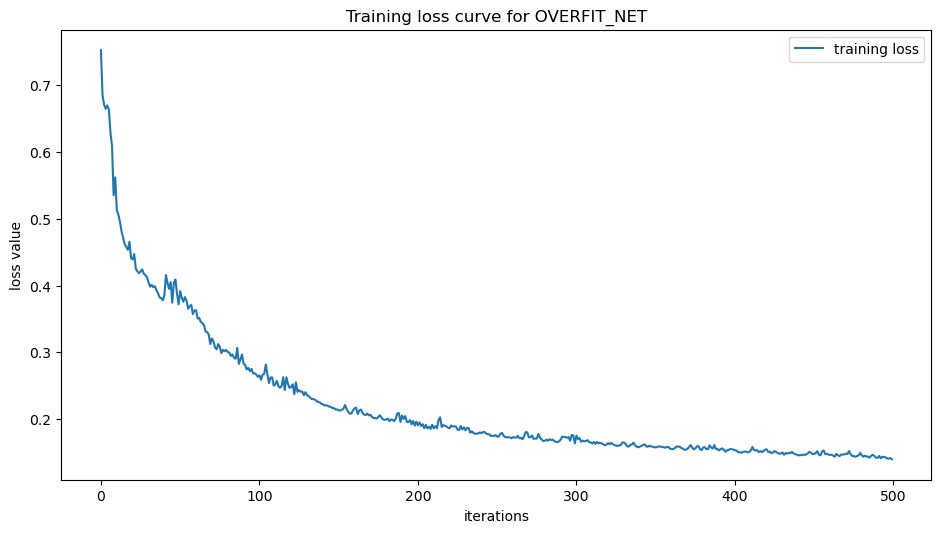

Now we run it on its own image and a random image in the set to compare its results

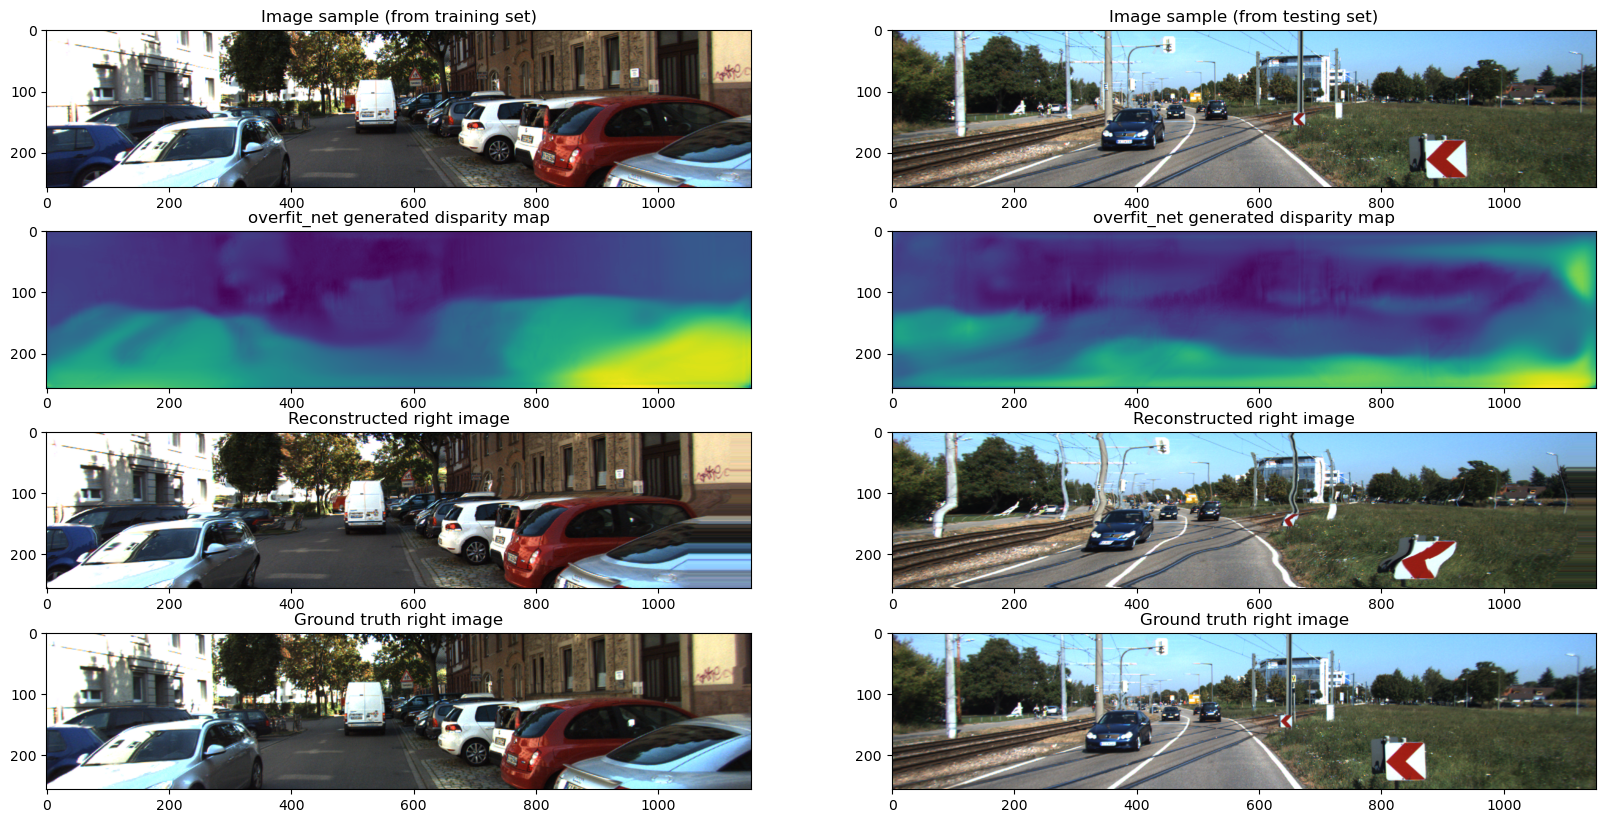

## Trained Model

Now for the model trained on the entire dataset

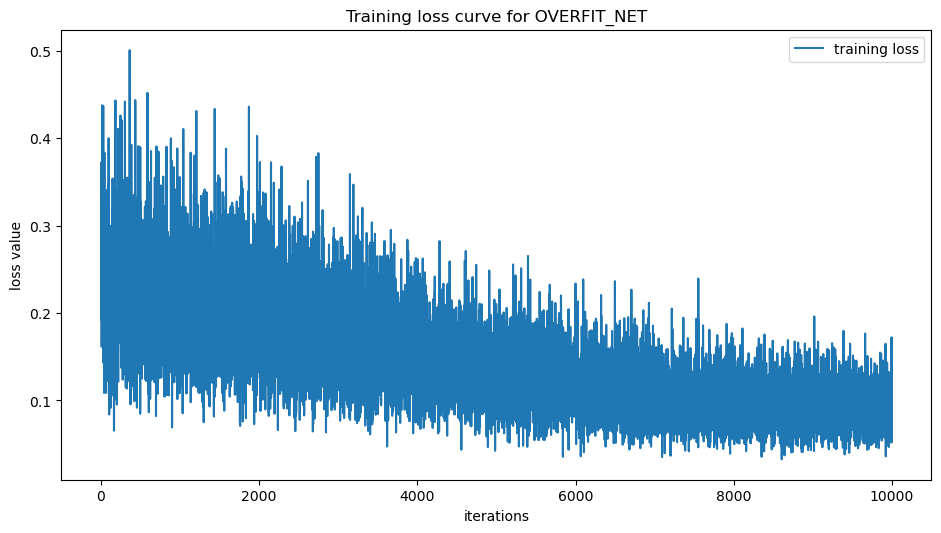

Similarly, we compare visually the results compared to the overfit image and another random image

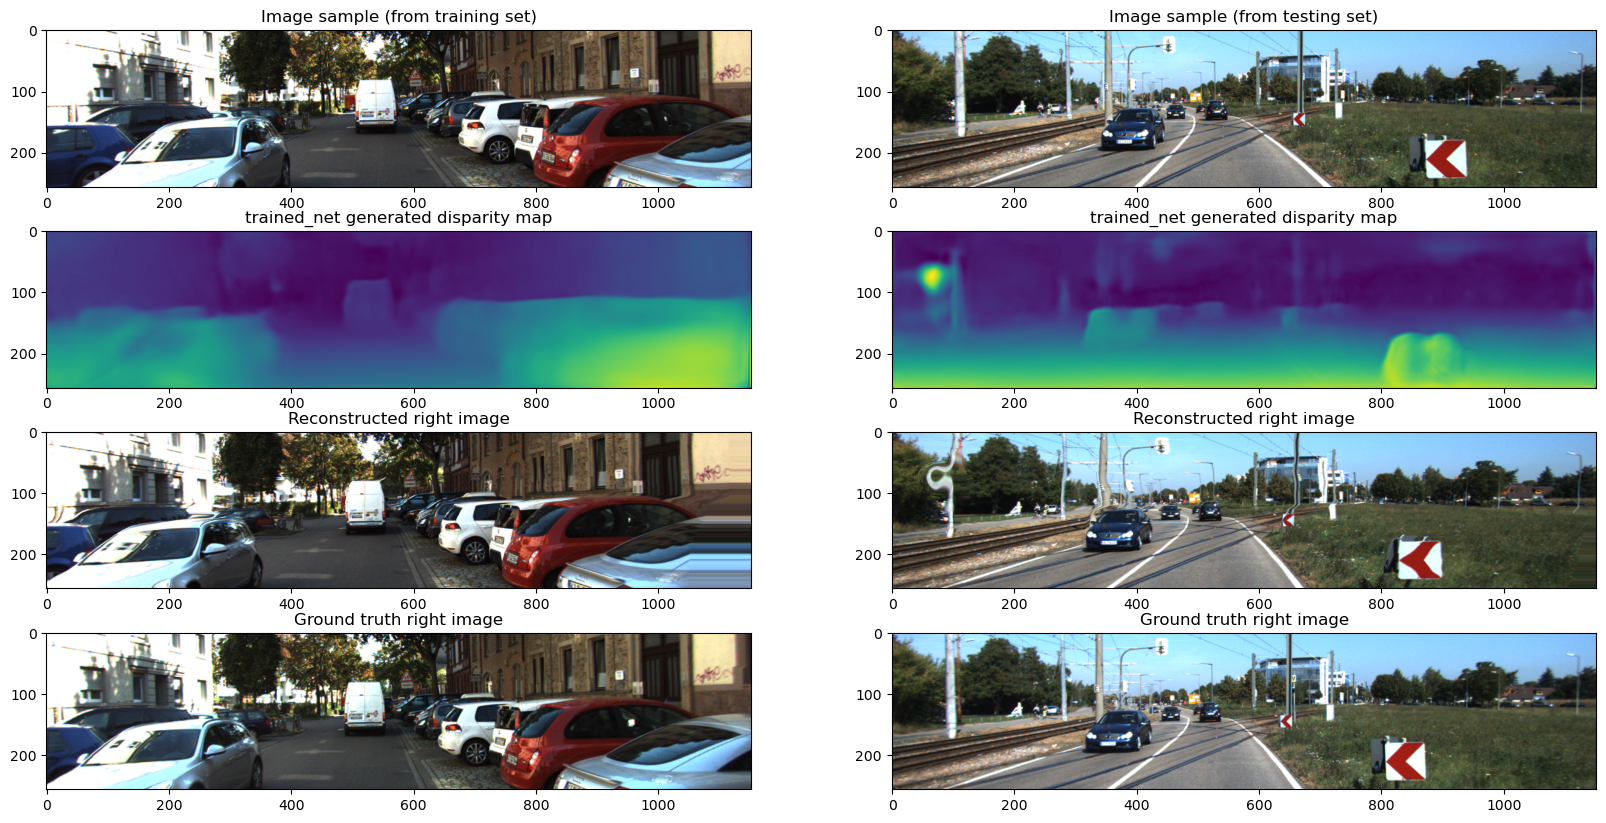

We can also see how the model perfoms with images far different from the driving landscape scenes it was trained on by seeing how it fares with the Tsuksuba example from class:

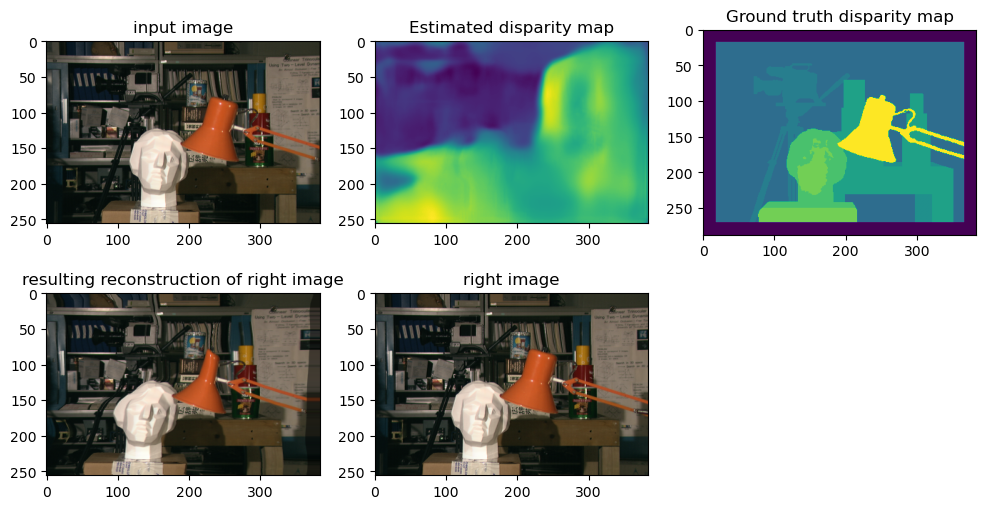

## Quantitative Validation

Without using ground truth disparities, it is difficult to construct meaningful validation metric. We started with the strucutral similarity index measure (SSIM), used as an intermediate in [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677)'s loss function. This resulted in values of around 0.995, 0.996, and 0.998 for untrained, overfit, and trained models over the validation dataset. These high values are due to the fact that stereo image pairs already have much structure in common.

If we instead use a simple photometric loss (being the mean absolute difference across all pixels between the expected and reproduced right images), we get slightly more meaningfull results. The photometric losses decrease from 0.111 and 0.101 for untrained and overfit to 0.066 for the validation dataset after training. This shows that the overtrained model performs only slightly better, but doesn't learn to generalize to unseen driving scenes as well as the trained model does.

In [56]:
%%time
print("Photometric loss for UNTRAINED_NET over the validation dataset:{}".format(validate(val_loader, untrained_net)))
print("Photometric loss for OVERFIT_NET over the training dataset:{}".format(validate(train_loader, overfit_net)))
print("Photometric loss for OVERFIT_NET over the validation dataset:{}".format(validate(val_loader, overfit_net)))
print("Photometric loss for TRAINED_NET over the training dataset:{}".format(validate(train_loader, trained_net)))
print("Photometric loss for TRAINED_NET over the validation dataset:{}".format(validate(val_loader, trained_net)))

Photometric loss for UNTRAINED_NET over the validation dataset:0.0939188078045845
Photometric loss for OVERFIT_NET over the training dataset:0.06902937591075897
Photometric loss for OVERFIT_NET over the validation dataset:0.1048368439078331
Photometric loss for TRAINED_NET over the training dataset:0.06387476623058319
Photometric loss for TRAINED_NET over the validation dataset:0.06719004362821579
CPU times: user 2min 22s, sys: 11.4 s, total: 2min 34s
Wall time: 25.7 s


## Conclusion

In the final analysis, we were mostly successful in creating a FCN capable of monocular depth estimation. Although it is not without error, the results from the trained model show the capacity to generalize beyond the training data and make meaningul estimates in a scene it was not trained on. We can observe this qualitatively in general accuracy of the depth maps produced, as well as quantitivley where the trained model performed as well on the unseen validation dataset as the training dataset. One limitation is the inability to generalize beyond the driving/landscape scenes it is familiar with, as observed in its failure on the Tsuksuba example from class.

Although the results are far from being as substantial as that of [\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677), our model trained on a much smaller subset of the data in much less time. Whereas they used took "25 hours" to train on "30 thousand images", we only trained on a set of 200 images in around 30 minutes. The simplicities and adjustements we made allowed our model to be trained more efficiently at the cost of accuracy. Perhaps in this right it is better suited for less critical, more specialized situations than automated driving.

As a continuation, we might explore how the model performs when trained on a different dataset than driving situations. Another exploration could involve assesing efficiency/accuracy tradeoff when using more than just the final disparity layer in training ([\[Godard et al., 2017\]](https://arxiv.org/pdf/1609.03677) uses all 4 `disp` layers, for example).

## Sources
Godard, Clément, et al. “Unsupervised Monocular Depth Estimation with Left-Right Consistency.” Computer Vision and Pattern Recognition, 21 July 2017, https://doi.org/10.1109/cvpr.2017.699.

Odena, Augustus, et al. “Deconvolution and Checkerboard Artifacts.” Distill, vol. 1, no. 10, 17 Oct. 2016, https://doi.org/10.23915/distill.00003.